In [19]:
import pandas as pd

df = pd.read_csv("smoke_detection_iot.csv")

# حذف عمود index المخفي (Unnamed)
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

# تنظيف أسماء الأعمدة
df.columns = df.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)

# حذف الأعمدة غير المهمة
df.drop(["UTC", "CNT"], axis=1, inplace=True)

# تقسيم البيانات
X = df.drop("Fire_Alarm", axis=1)
y = df["Fire_Alarm"]

In [20]:
X

,Temperature_C_,Humidity_,TVOC_ppb_,eCO2_ppm_,Raw_H2,Raw_Ethanol,Pressure_hPa_,PM1_0,PM2_5,NC0_5,NC1_0,NC2_5
0,20.000,57.36,0,400,12306,18520,939.735,0.00,0.00,0.00,0.000,0.000
1,20.015,56.67,0,400,12345,18651,939.744,0.00,0.00,0.00,0.000,0.000
2,20.029,55.96,0,400,12374,18764,939.738,0.00,0.00,0.00,0.000,0.000
3,20.044,55.28,0,400,12390,18849,939.736,0.00,0.00,0.00,0.000,0.000
4,20.059,54.69,0,400,12403,18921,939.744,0.00,0.00,0.00,0.000,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...
62625,18.438,15.79,625,400,13723,20569,936.670,0.63,0.65,4.32,0.673,0.015
62626,18.653,15.87,612,400,13731,20588,936.678,0.61,0.63,4.18,0.652,0.015
62627,18.867,15.84,627,400,13725,20582,936.687,0.57,0.60,3.95,0.617,0.014
62628,19.083,16.04,638,400,13712,20566,936.680,0.57,0.59,3.92,0.611,0.014


In [21]:
print(X.columns)

Index(['Temperature_C_', 'Humidity_', 'TVOC_ppb_', 'eCO2_ppm_', 'Raw_H2',
       'Raw_Ethanol', 'Pressure_hPa_', 'PM1_0', 'PM2_5', 'NC0_5', 'NC1_0',
       'NC2_5'],
      dtype='object')


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [23]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss"
)

In [24]:
model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [25]:
y_pred = model.predict(X_test)

In [26]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9999201660546064


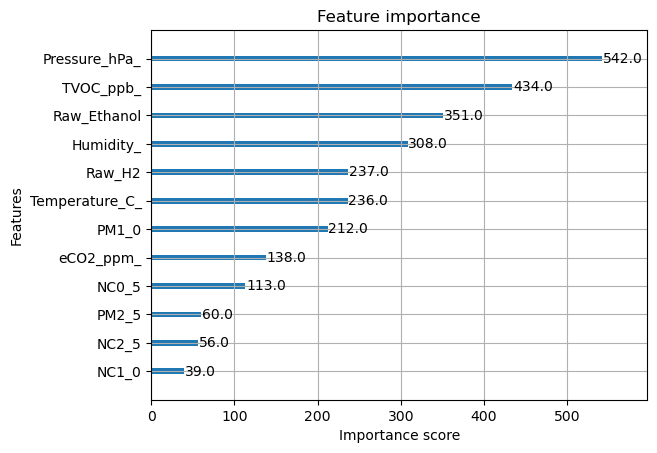

In [27]:
import matplotlib.pyplot as plt

from xgboost import plot_importance
plot_importance(model)
plt.show()

In [28]:
import joblib

joblib.dump(model, "smoke_xgboost_model.pkl")

['smoke_xgboost_model.pkl']

In [29]:
joblib.dump(X_train.columns.tolist(), "model_features.pkl")

['model_features.pkl']